# Weekly Average Forecasting of Citywide  Rat Sightings

We ask if forecasting at a citywide level at a weekly basis can smooth out the issue of there being many outliers at the daily level. 
Since we are inevitably interested in the daily number of rat sightings, we attempt to forecast the weekly average number of rat sightings reported. One reason for doing would be that it could inform city planners of how many workers they need at hand during certain weeks to handly rat sightings reports.

In this notebook, we experiment to see if some of the models we had considered before can predict the weekly average well.

Since we only making some preliminary tests, we use data from 2020-01-01 to 2026-02-28 for this notebook.

# Import Packages

In [12]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression

from prophet import Prophet
from pandas.tseries.holiday import USFederalHolidayCalendar
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from prophet.plot import add_changepoints_to_plot
import itertools

import logging
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('pytorch_lightning').setLevel(logging.ERROR)

import xgboost as xgb
from xgboost import plot_importance

# Time Series Split

In [13]:
# this is the time series split we will work with
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=2)

# Importing the Data

In [14]:
# we import the data and clean it for future use
rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
# mark cutoff dates, and also rename columns
rs = rs[rs['created_date']<'2026-03-01']
rs = rs[rs['created_date']>='2020-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')

In [15]:
rs = rs.set_index('created_date')

rs = rs.reindex(pd.date_range(rs.index.min(), rs.index.max(), freq='D'), fill_value=0)

rs = rs.rename_axis('created_date').reset_index()

In [16]:
## We find the missing row and add it in.
## There's probably a better way to find in the missing dates and update it. This is a sort of hacky solution.

# date_range = pd.date_range(start=rs['created_date'].min(), end=rs['created_date'].max(), freq='D')
# complete_dates_df = pd.DataFrame(date_range, columns=['created_date'])
# rs = pd.merge(complete_dates_df, rs, on='created_date', how='left')
# rs['count'] = rs['count'].fillna(0).astype(int)
# rs = rs.sort_values(by='created_date').reset_index(drop=True)


In [17]:
# Rename columns for Prophet model
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

# Ensure ds is datetime
rs['ds'] = pd.to_datetime(rs['ds'])

# Aggregate data to weekly average
rs_weekly = rs.set_index('ds').resample('W')['y'].mean().reset_index()
rs_weekly.columns = ['ds', 'y']

# Create dataframe explaining week ranges
week_explanation = rs_weekly[['ds']].copy()
week_explanation['week_start'] = week_explanation['ds'] - pd.Timedelta(days=6)
week_explanation['week_end'] = week_explanation['ds']
week_explanation = week_explanation[['week_start', 'week_end', 'ds']]

In [18]:
rs_weekly

,ds,y
0,2020-01-05,28.000000
1,2020-01-12,33.714286
2,2020-01-19,34.857143
3,2020-01-26,35.571429
4,2020-02-02,35.571429
...,...,...
317,2026-02-01,20.428571
318,2026-02-08,23.571429
319,2026-02-15,27.285714
320,2026-02-22,36.428571


In [19]:
week_explanation

,week_start,week_end,ds
0,2019-12-30,2020-01-05,2020-01-05
1,2020-01-06,2020-01-12,2020-01-12
2,2020-01-13,2020-01-19,2020-01-19
3,2020-01-20,2020-01-26,2020-01-26
4,2020-01-27,2020-02-02,2020-02-02
...,...,...,...
317,2026-01-26,2026-02-01,2026-02-01
318,2026-02-02,2026-02-08,2026-02-08
319,2026-02-09,2026-02-15,2026-02-15
320,2026-02-16,2026-02-22,2026-02-22


# Baseline Seasonal Average Model

In [20]:
def seasonal_average_forecast_weekly(data, target_dates, years_back=4, week_window=1):
    
    df = data.copy()
    
    # Ensure datetime
    df["ds"] = pd.to_datetime(df["ds"])
    
    # Extract seasonal features
    df["week"] = df["ds"].dt.isocalendar().week.astype(int)
    df["year"] = df["ds"].dt.year

    forecasts = []

    for target_date in target_dates:
        
        target_week = target_date.isocalendar().week
        target_year = target_date.year
        
        mask = (
            (df["year"] >= target_year - years_back) &
            (df["year"] < target_year) &
            (np.abs(df["week"] - target_week) <= week_window)
        )
        
        forecasts.append(df.loc[mask, "y"].mean())

    return pd.Series(forecasts, index=target_dates)

In [21]:
results = []

rs_weekly["ds"] = pd.to_datetime(rs_weekly["ds"])

for i, (train_index, test_index) in enumerate(tscv.split(rs_weekly)):
    
    train = rs_weekly.iloc[train_index].copy()
    test = rs_weekly.iloc[test_index].copy()
    
    # Target weeks we want to forecast
    target_dates = test["ds"]
    # Weekly seasonal forecast
    y_pred = seasonal_average_forecast_weekly(data=train, target_dates=target_dates, years_back=4, week_window=1)

    y_true = test["y"].values
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    results.append({"fold": i,"rmse": rmse,"mape": mape})

baseline_results_df = pd.DataFrame(results)

# Add mean row
baseline_results_df.loc["mean"] = ["mean",baseline_results_df["rmse"].mean(),baseline_results_df["mape"].mean()]

In [22]:
baseline_results_df

,fold,rmse,mape
0,0,5.825365,0.076953
1,1,3.916694,0.052226
2,2,11.132881,0.179014
3,3,13.084620,0.207009
4,4,12.738020,0.183939
5,5,18.305338,0.271872
6,6,12.760153,0.174202
7,7,8.316488,0.102787
8,8,11.059062,0.144379
9,9,19.656756,0.264844


Notice that the RMSE of the baseline model drops drastically in comparison to the situation with daily forecasting. This is a good sign that taking weekly averages "smooths" away the outliers that occur.

# Prophet Model

In [23]:
# Create a date range covering 2020 through end of 2025
date_range = pd.date_range(start="2020-01-01", end="2026-02-28")


# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())
federal_holidays = pd.DataFrame({'holiday': 'federal_us','ds': pd.to_datetime(holidays),'lower_window': 0,'upper_window': 1,})

holidays = federal_holidays

In [24]:
# Disable all logging
logging.disable(logging.CRITICAL)

In [26]:
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs_weekly)):
    train = rs_weekly.iloc[train_index]
    test = rs_weekly.iloc[test_index]
    
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')
    model.fit(train)
    
    # Calculate number of weeks to forecast
    num_forecast_weeks = len(test)
    future = model.make_future_dataframe(periods=num_forecast_weeks, freq='W')
    forecast = model.predict(future)
    
    # Obtain predicted values and compare against the actuals.
    y_pred = forecast['yhat'][-num_forecast_weeks:].values
    y_true = test['y'].values
    
    # Metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append results
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

# Re-enable logging after Prophet modeling
logging.disable(logging.NOTSET)

# Convert results to a datafrane
prophet_results_df = pd.DataFrame(results)
prophet_results_df.loc['mean'] = ['mean',  prophet_results_df['rmse'].mean(), prophet_results_df['mape'].mean()]

In [27]:
prophet_results_df

,fold,rmse,mape
0,0,5.095143,0.086314
1,1,4.802575,0.064353
2,2,3.155734,0.049612
3,3,4.625917,0.064780
4,4,4.333419,0.061880
5,5,12.509894,0.166021
6,6,4.709019,0.064174
7,7,3.190539,0.039779
8,8,3.424949,0.038403
9,9,9.112166,0.116072


# SARIMA Model

We can see if SARIMA makes better predictions. The main issue with SARIMA and using it for daily data was the number of lags that would be needed to take into account for yearly seasonality. At a weekly level, this issue is lifted.

In [28]:
from pmdarima import auto_arima

In [29]:
def fourier_terms(df, period, n_terms):
    t = np.arange(1, len(df) + 1)
    fourier_df = pd.DataFrame()
    
    for i in range(1, n_terms + 1):
        fourier_df[f'sin_{i}'] = np.sin(2 * np.pi * i * t / period)
        fourier_df[f'cos_{i}'] = np.cos(2 * np.pi * i * t / period)
    
    return fourier_df

# Number of Fourier terms and period 
n_terms = 30
period = 26 

fourier_train = fourier_terms(rs, period, n_terms)
# Name it exog since it will serve as exogenous features for SARIMAX. This is the X.
exog = fourier_train

In [30]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

results = []

# Ensure proper order
rs_weekly = rs_weekly.sort_values("ds").reset_index(drop=True)

# Loop through each fold
for i, (train_index, test_index) in enumerate(tscv.split(rs_weekly)):
    
    train = rs_weekly.iloc[train_index]
    test = rs_weekly.iloc[test_index]

    exog_train = exog.iloc[train_index]
    exog_test = exog.iloc[test_index]

    model_auto = auto_arima(train['y'], exog=exog_train, trace=True, stepwise=True, suppress_warnings=True, n_jobs=-1)

    orders = model_auto.order
    seasonal_orders = model_auto.seasonal_order

    # Fit SARIMAX
    model_sarimax = SARIMAX(train['y'], order=orders, exog=exog_train,
                            seasonal_order=seasonal_orders, 
                            enforce_stationarity=False, enforce_invertibility=False)

    model_fit = model_sarimax.fit(disp=False)

    # Forecast for test period
    y_pred = model_fit.predict(start=len(train), end=len(train) + len(test) - 1, exog=exog_test, dynamic=False)

    y_true = test['y'].values

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)

    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

sarima_results_df = pd.DataFrame(results)
sarima_results_df.loc['mean'] = ['mean',  sarima_results_df['rmse'].mean(), sarima_results_df['mape'].mean()]

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1935.246, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1947.931, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1938.025, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1934.018, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1945.959, Time=0.00 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1933.995, Time=0.03 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1935.689, Time=0.04 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1933.719, Time=0.02 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=1935.566, Time=0.03 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=1936.136, Time=0.08 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=1931.759, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1932.055, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=1933.729, Time=0.03 sec
 ARIMA(0,1,3)(0,0,0)[0]             : 

/opt/anaconda3/envs/RSNYCEnv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1949.571, Time=0.19 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1961.418, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1951.669, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1947.957, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1959.474, Time=0.00 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1948.028, Time=0.03 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1947.808, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1949.768, Time=0.04 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=1949.604, Time=0.03 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=1950.160, Time=0.06 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=1945.900, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1946.043, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=1947.860, Time=0.03 sec
 ARIMA(0,1,3)(0,0,0)[0]             : AIC=1947.695, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0]          

/opt/anaconda3/envs/RSNYCEnv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1962.205, Time=0.22 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1974.223, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1964.444, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1960.659, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1972.263, Time=0.00 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1960.651, Time=0.03 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.07 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1962.375, Time=0.05 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1960.415, Time=0.02 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=1962.214, Time=0.03 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=1962.806, Time=0.06 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=1958.503, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1958.737, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=1960.463, Time=0.03 sec
 ARIMA(0,1,3)(0,0,0)[0]             : 

...

/opt/anaconda3/envs/RSNYCEnv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=2260.643, Time=0.29 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2276.185, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2263.230, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2259.166, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2274.187, Time=0.00 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2259.374, Time=0.03 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=2259.274, Time=0.03 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=2261.216, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=2257.170, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=2257.378, Time=0.02 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=2257.278, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=2261.233, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=2259.220, Time=0.03 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 0.539 seconds


/opt/anaconda3/envs/RSNYCEnv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=2272.883, Time=0.29 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2288.830, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2275.767, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2271.594, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2286.830, Time=0.00 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2271.738, Time=0.03 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=2271.625, Time=0.03 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=2273.567, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=2269.595, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=2269.739, Time=0.02 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=2269.626, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=2273.767, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=2271.568, Time=0.03 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 0.568 seconds


/opt/anaconda3/envs/RSNYCEnv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [31]:
sarima_results_df

,fold,rmse,mape
0,0,9.462627,0.155428
1,1,11.622076,0.150595
2,2,5.321588,0.083026
3,3,9.113250,0.145937
4,4,5.416300,0.078164
5,5,12.391609,0.189936
6,6,4.847110,0.065916
7,7,9.556022,0.121880
8,8,9.922115,0.135062
9,9,9.414444,0.120671


In [32]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [33]:
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs_weekly)):
    
    train = rs_weekly.iloc[train_index]
    test = rs_weekly.iloc[test_index]
    
    holt_winters = ExponentialSmoothing(train['y'], seasonal='add', seasonal_periods=26).fit(optimized=True)
    y_pred = holt_winters.forecast(len(test))
    y_true = test['y'].values

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

hw_results_df = pd.DataFrame(results)
hw_results_df.loc['mean'] = ['mean',  hw_results_df['rmse'].mean(), hw_results_df['mape'].mean()]

In [34]:
hw_results_df

,fold,rmse,mape
0,0,10.647413,0.159074
1,1,1.808046,0.028783
2,2,2.309630,0.030154
3,3,8.040372,0.111651
4,4,2.285332,0.024211
5,5,3.408909,0.045109
6,6,9.111568,0.124229
7,7,8.798071,0.110722
8,8,6.689559,0.075923
9,9,4.032955,0.055775


# XGBoost Model

The XGBoost model requires a bit more preparatory work. Our current dataframe rs_weekly is quite bare and we should features for use.

## Adding Features to XGBoost

In [35]:
def create_weekly_features(df, forecast_horizon_weeks=2):
    df = df.copy()
    df["ds"] = pd.to_datetime(df["ds"])
    df = df.sort_values("ds")

    df["year"] = df["ds"].dt.year
    df["quarter"] = df["ds"].dt.quarter
    df["month"] = df["ds"].dt.month
    df["weekofyear"] = df["ds"].dt.isocalendar().week.astype(int)


    df["weekofyear_sin"] = np.sin(2 * np.pi * df["weekofyear"] / 52)
    df["weekofyear_cos"] = np.cos(2 * np.pi * df["weekofyear"] / 52)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)



    shift = forecast_horizon_weeks
    df["lag1"] = df["y"].shift(shift + 1)
    df["lag2"] = df["y"].shift(shift + 2)
    df["lag3"] = df["y"].shift(shift + 3)
    df["lag4"] = df["y"].shift(shift + 4)
    df["lag8"] = df["y"].shift(shift + 8)
    df["lag12"] = df["y"].shift(shift + 12)
    df["lag26"] = df["y"].shift(shift + 26)
    df["lag52"] = df["y"].shift(shift + 52)
    df["lag104"] = df["y"].shift(shift + 104)



    df["ma4"] = df["y"].shift(shift).rolling(4).mean()
    df["ma8"] = df["y"].shift(shift).rolling(8).mean()
    df["ma12"] = df["y"].shift(shift).rolling(12).mean()
    df["ma26"] = df["y"].shift(shift).rolling(26).mean()
    df["ma52"] = df["y"].shift(shift).rolling(52).mean()

    return df

In [36]:
## Add weekly average weather data

import requests
import pandas as pd

lat, lon = 40.7831, -73.9712
start = "2020-01-01"
end   = "2026-02-28"

url = ("https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_mean"
    "&timezone=America/New_York")

response = requests.get(url)
data = response.json()



wd = pd.DataFrame(data["daily"])
wd["date"] = pd.to_datetime(wd["time"])
wd = wd.set_index("date")
wd = wd.drop(columns=["time"])

# Convert daily weather to weekly averages
wd_weekly = (wd.resample("W").mean().rename(columns={"temperature_2m_mean": "weekly_avg_temp"}))

def add_weather_data_weekly(df, wd_weekly):
    df = df.copy()
    wd_weekly = wd_weekly.copy()
    df["ds"] = pd.to_datetime(df["ds"])
    wd_weekly.index = pd.to_datetime(wd_weekly.index)
    df = df.merge(wd_weekly,left_on="ds",right_index=True,how="left")

    return df

In [37]:
from pandas.tseries.holiday import USFederalHolidayCalendar
import pandas as pd

def add_weekly_federal_holidays(df, custom_holidays=None):
    df = df.copy()
    df["ds"] = pd.to_datetime(df["ds"])
    
    cal = USFederalHolidayCalendar()
    holidays = cal.holidays(start=df["ds"].min(),end=df["ds"].max())

    if custom_holidays:
        for d in custom_holidays:
            if len(d) == 5:  # MM-DD format
                years = df["ds"].dt.year.unique()
                for y in years:
                    holidays = pd.concat([
                        holidays,
                        pd.to_datetime([f"{y}-{d}"])
                    ])
            else:  # YYYY-MM-DD format
                holidays = pd.concat([
                    holidays,
                    pd.to_datetime([d])
                ])

    holidays = pd.to_datetime(holidays).drop_duplicates()

    # Determine week range (Monday–Sunday since resample('W') ends on Sunday)
    df["week_start"] = df["ds"] - pd.Timedelta(days=6)
    df["week_end"] = df["ds"]

    # Check if any holiday falls inside each week
    def week_has_holiday(row):
        return int(((holidays >= row["week_start"]) &(holidays <= row["week_end"])).any())

    df["has_federal_holiday"] = df.apply(week_has_holiday, axis=1)

    return df.drop(columns=["week_start", "week_end"])

In [38]:
def add_weekly_weather_lags(df, forecast_horizon_weeks=2):
    df = df.copy()
    df = df.sort_values("ds")
    df["ds"] = pd.to_datetime(df["ds"])
    df = df.set_index("ds")

    shift = forecast_horizon_weeks

    # Weekly temperature lags
    df["weekly_avg_temp_lag1"] = df["weekly_avg_temp"].shift(shift + 1)
    df["weekly_avg_temp_lag2"] = df["weekly_avg_temp"].shift(shift + 2)
    df["weekly_avg_temp_lag4"] = df["weekly_avg_temp"].shift(shift + 4)
    df["weekly_avg_temp_lag8"] = df["weekly_avg_temp"].shift(shift + 8)
    df["weekly_avg_temp_lag12"] = df["weekly_avg_temp"].shift(shift + 12)

    # Yearly seasonal lags (very important for weather)
    df["weekly_avg_temp_lag52"] = df["weekly_avg_temp"].shift(52)
    df["weekly_avg_temp_lag104"] = df["weekly_avg_temp"].shift(104)

    return df.reset_index()

In [39]:
rs_weekly = rs_weekly.sort_values("ds").reset_index(drop=True)

rs_weekly = create_weekly_features(rs_weekly, forecast_horizon_weeks=14)
rs_weekly = add_weather_data_weekly(rs_weekly, wd_weekly)
rs_weekly = add_weekly_weather_lags(rs_weekly, forecast_horizon_weeks=14)

rs_weekly = add_weekly_federal_holidays(rs_weekly)

In [40]:
rs_weekly.columns

Index(['ds', 'y', 'year', 'quarter', 'month', 'weekofyear', 'weekofyear_sin',
       'weekofyear_cos', 'month_sin', 'month_cos', 'lag1', 'lag2', 'lag3',
       'lag4', 'lag8', 'lag12', 'lag26', 'lag52', 'lag104', 'ma4', 'ma8',
       'ma12', 'ma26', 'ma52', 'weekly_avg_temp', 'weekly_avg_temp_lag1',
       'weekly_avg_temp_lag2', 'weekly_avg_temp_lag4', 'weekly_avg_temp_lag8',
       'weekly_avg_temp_lag12', 'weekly_avg_temp_lag52',
       'weekly_avg_temp_lag104', 'has_federal_holiday'],
      dtype='object')

In [41]:
FEATURES = ['year', 'quarter', 'month', 'weekofyear', 'weekofyear_sin',
       'weekofyear_cos', 'month_sin', 'month_cos', 'lag1', 'lag2', 'lag3',
       'lag4', 'lag8', 'lag12', 'lag26', 'lag52', 'lag104', 'ma4', 'ma8',
       'ma12', 'ma26', 'ma52', 'weekly_avg_temp', 'weekly_avg_temp_lag1',
       'weekly_avg_temp_lag2', 'weekly_avg_temp_lag4', 'weekly_avg_temp_lag8',
       'weekly_avg_temp_lag12', 'weekly_avg_temp_lag52', 'weekly_avg_temp_lag104', 'has_federal_holiday']


## Add default parameters for XGBoost

In [42]:
params = {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'booster': 'gbtree', 
          'base_score': 0.5, 'n_estimators': 100, 
          'min_child_weight': 7, 'learning_rate': 0.01, 
          'max_depth': 8}

## uncomment to use GPU
params.update({"tree_method": "hist", "device": "cuda"})


## Results for XGBoost Model

In [43]:
TARGET = "y"

# Initialize model
reg = xgb.XGBRegressor(**params)

results = []
for i, (train_index, test_index) in enumerate(tscv.split(rs_weekly)):
    
    train = rs_weekly.iloc[train_index]
    test = rs_weekly.iloc[test_index]
    
    # Fit model
    reg.fit(train[FEATURES], train[TARGET])
    
    # Predict
    y_pred = reg.predict(test[FEATURES])
    y_true = test[TARGET].values
    
    # Metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    results.append({"fold": i, "rmse": rmse, "mape": mape})
    
    print(results)

# Convert to DataFrame
xgb_results_df = pd.DataFrame(results)

# Add mean row
mean_rmse = xgb_results_df["rmse"].mean()
mean_mape = xgb_results_df["mape"].mean()

xgb_results_df.loc["mean"] = ["mean", mean_rmse, mean_mape]

[{'fold': 0, 'rmse': 20.31909180124251, 'mape': 0.34671569471835867}]
[{'fold': 0, 'rmse': 20.31909180124251, 'mape': 0.34671569471835867}, {'fold': 1, 'rmse': 24.83202111395798, 'mape': 0.40891321672964065}]
[{'fold': 0, 'rmse': 20.31909180124251, 'mape': 0.34671569471835867}, {'fold': 1, 'rmse': 24.83202111395798, 'mape': 0.40891321672964065}, {'fold': 2, 'rmse': 16.992891284402887, 'mape': 0.2521546086321302}]
[{'fold': 0, 'rmse': 20.31909180124251, 'mape': 0.34671569471835867}, {'fold': 1, 'rmse': 24.83202111395798, 'mape': 0.40891321672964065}, {'fold': 2, 'rmse': 16.992891284402887, 'mape': 0.2521546086321302}, {'fold': 3, 'rmse': 13.248520005597642, 'mape': 0.20339422125624051}]
[{'fold': 0, 'rmse': 20.31909180124251, 'mape': 0.34671569471835867}, {'fold': 1, 'rmse': 24.83202111395798, 'mape': 0.40891321672964065}, {'fold': 2, 'rmse': 16.992891284402887, 'mape': 0.2521546086321302}, {'fold': 3, 'rmse': 13.248520005597642, 'mape': 0.20339422125624051}, {'fold': 4, 'rmse': 16.6509

In [44]:
xgb_results_df

,fold,rmse,mape
0,0,20.319092,0.346716
1,1,24.832021,0.408913
2,2,16.992891,0.252155
3,3,13.248520,0.203394
4,4,16.650913,0.237234
5,5,17.992501,0.257263
6,6,25.306771,0.345691
7,7,27.882220,0.350063
8,8,20.895104,0.282617
9,9,20.738442,0.285676


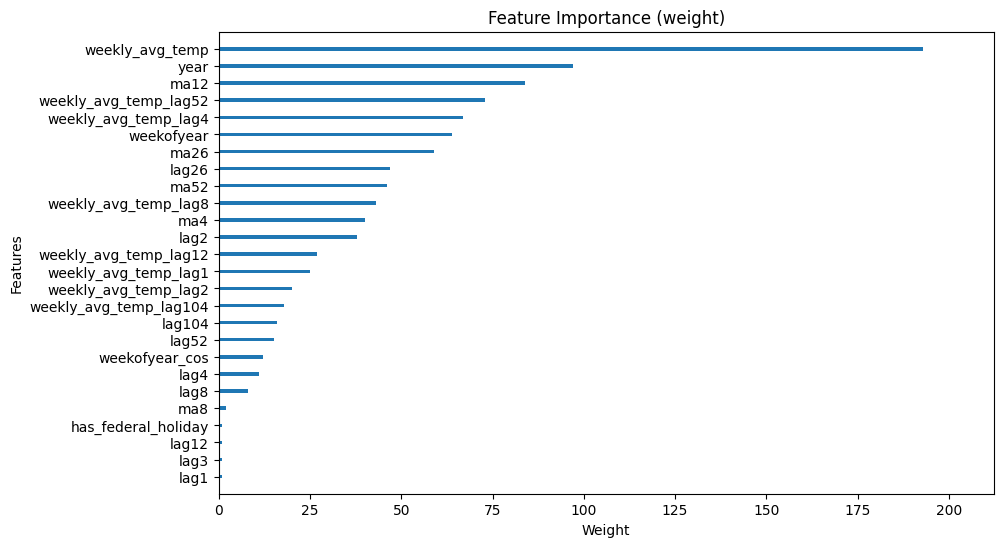

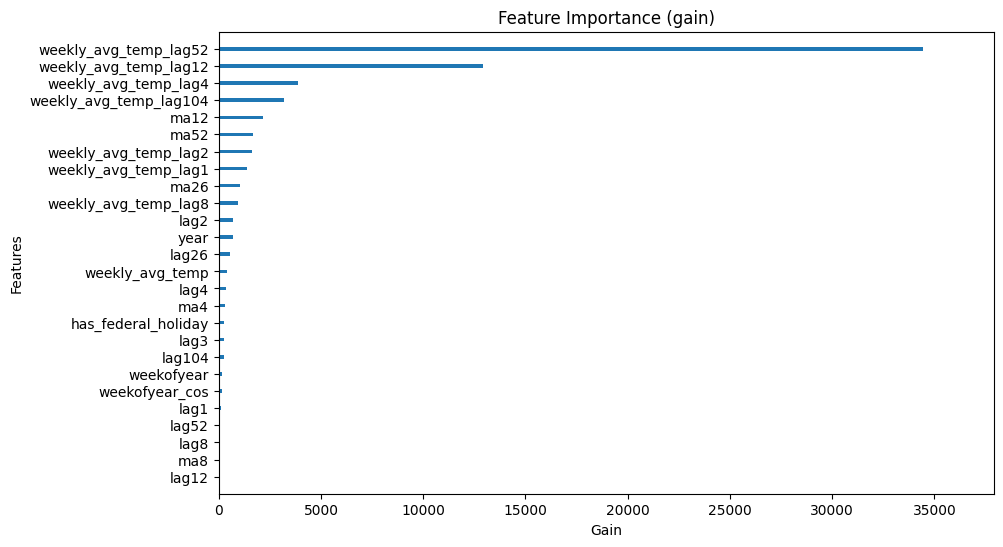

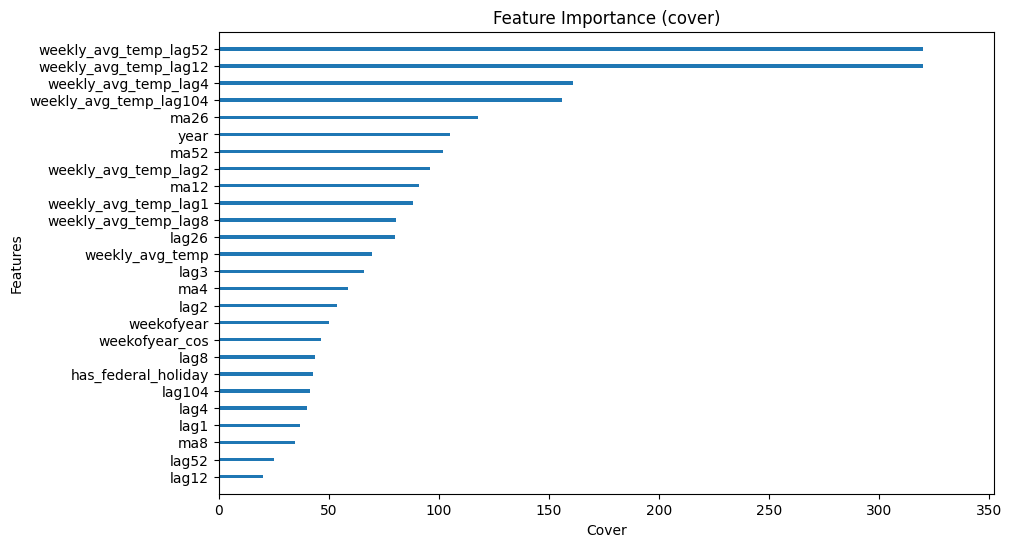

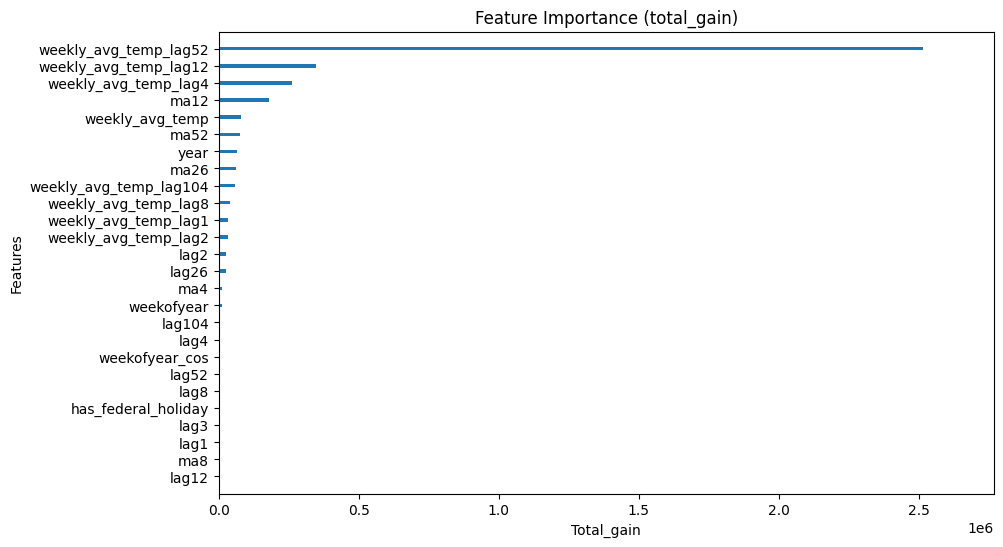

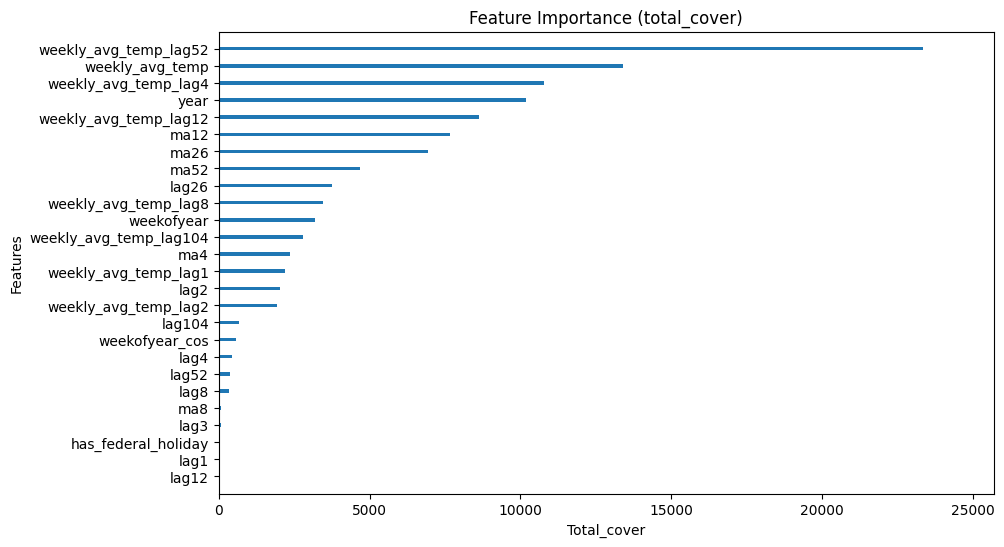

In [45]:
model = reg.fit(train[FEATURES], train[TARGET])
importance_types = ['weight', 'gain', 'cover', 'total_gain', 'total_cover']
for importance_type in importance_types:
    fig, ax = plt.subplots(figsize=(10, 6))
    xgb.plot_importance(model, ax=ax, importance_type=importance_type, grid=False, show_values=False)
    plt.xlabel(f'{importance_type}'.capitalize())
    plt.title(f'Feature Importance ({importance_type})')
    plt.show()

# Results Table

In [46]:
models = {'baseline': baseline_results_df, 'prophet': prophet_results_df, 'sarima': sarima_results_df, 'hw': hw_results_df, 'xgb': xgb_results_df,}

all_results = []
for model_name, df in models.items():
    df['model'] = model_name
    all_results.append(df)

final_results_df = pd.concat(all_results, ignore_index=True)
final_table = final_results_df.pivot(index='fold', columns='model', values=['rmse', 'mape'])
final_table.index = final_table.index.where(final_table.index != '-', 'mean')

final_table

rmse                                                  mape  \
model   baseline         hw    prophet     sarima        xgb  baseline   
fold                                                                     
0       5.825365  10.647413   5.095143   9.462627  20.319092  0.076953   
1       3.916694   1.808046   4.802575  11.622076  24.832021  0.052226   
2      11.132881   2.309630   3.155734   5.321588  16.992891  0.179014   
3      13.084620   8.040372   4.625917   9.113250  13.248520  0.207009   
4      12.738020   2.285332   4.333419   5.416300  16.650913  0.183939   
5      18.305338   3.408909  12.509894  12.391609  17.992501  0.271872   
6      12.760153   9.111568   4.709019   4.847110  25.306771  0.174202   
7       8.316488   8.798071   3.190539   9.556022  27.882220  0.102787   
8      11.059062   6.689559   3.424949   9.922115  20.895104  0.144379   
9      19.656756   4.032955   9.112166   9.414444  20.738442  0.264844   
10     24.139583   6.318621  13.937683   8.421242  19.465218  0.347113   
11     18.434548   1.949342   8.560221  10.455347  20.621384  0.267191   
12     14.958465   2.833547   4.266941   1.683278  23.068484  0.213088   
13      9.431686   4.435103   3.691856   6.848291  26.002768  0.129005   
14     28.764232  20.801593  17.057696  26.997144   4.508556  0.567684   
15     23.250809   2.687711   9.790205   4.099173   8.479201  0.457615   
16     26.970664  11.578703  12.896006  10.784221   3.620769  0.640891   
17     30.946256  12.802343  16.509239  16.719303   2.328448  0.943505   
18     18.185622   6.712234   4.476681   6.444923   2.946073  0.529229   
19     17.427378   7.457006   6.336645   8.603062   9.647491  0.587488   
20     21.119157   9.125418   5.296182   7.238749   3.444932  0.915434   
21     24.708334   2.537719   6.243923   9.914570   3.204589  1.089621   
22     15.981392   8.308925   3.221673   4.077231  11.933611  0.445791   
23     30.615645  13.236506  11.756874   9.549284   3.788082  1.311656   
24     29.392819   5.039942   4.796588   6.795753   4.040762  1.165141   
25     26.481682   4.994218   7.554267   5.327320   2.409924  0.843021   
mean   18.369371   6.844261   7.359694   8.885617  13.629568  0.465796   

                                               
model        hw   prophet    sarima       xgb  
fold                                           
0      0.159074  0.086314  0.155428  0.346716  
1      0.028783  0.064353  0.150595  0.408913  
2      0.030154  0.049612  0.083026  0.252155  
3      0.111651  0.064780  0.145937  0.203394  
4      0.024211  0.061880  0.078164  0.237234  
5      0.045109  0.166021  0.189936  0.257263  
6      0.124229  0.064174  0.065916  0.345691  
7      0.110722  0.039779  0.121880  0.350063  
8      0.075923  0.038403  0.135062  0.282617  
9      0.055775  0.116072  0.120671  0.285676  
10     0.074310  0.199419  0.121993  0.278786  
11     0.022123  0.124079  0.147144  0.298584  
12     0.038893  0.050675  0.018766  0.324115  
13     0.058394  0.038220  0.076889  0.357217  
14     0.408066  0.336313  0.527923  0.088910  
15     0.049533  0.188459  0.068831  0.161387  
16     0.271061  0.306132  0.236458  0.086059  
17     0.390433  0.496947  0.508014  0.068661  
18     0.148133  0.118494  0.171797  0.082054  
19     0.231518  0.191880  0.279415  0.222551  
20     0.384027  0.229532  0.308715  0.149574  
21     0.114042  0.287344  0.417192  0.147585  
22     0.231328  0.082075  0.096750  0.332892  
23     0.566633  0.503233  0.408390  0.159373  
24     0.191465  0.185164  0.235077  0.143882  
25     0.105151  0.222289  0.162458  0.067615  
mean   0.155798  0.165832  0.193555  0.228422

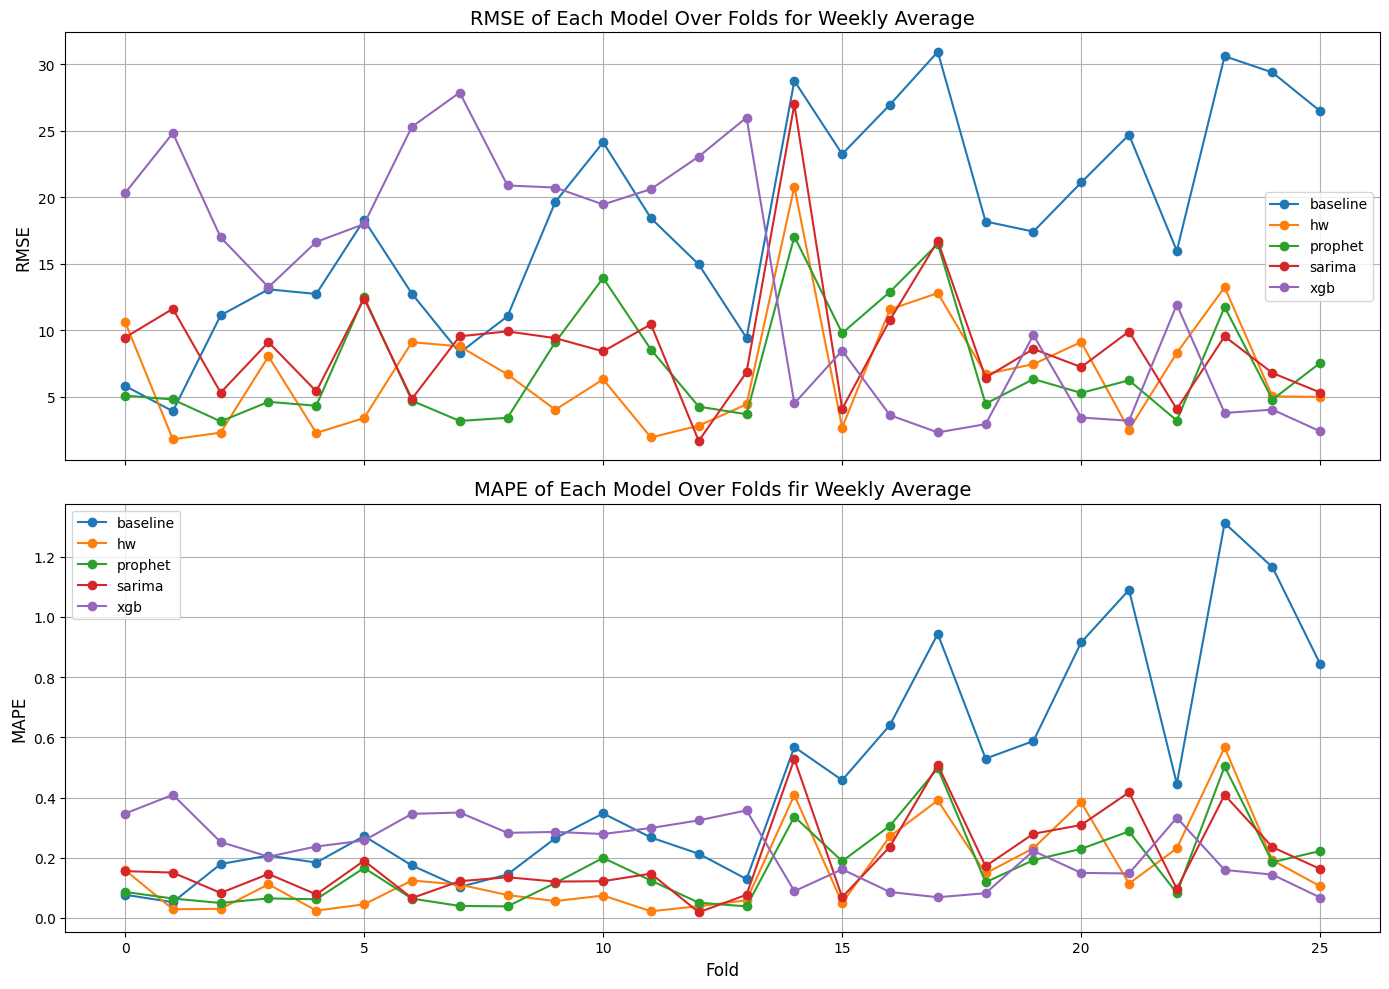

In [47]:
import matplotlib.pyplot as plt

# Make a copy and drop 'mean' row if present
plot_table = final_table.drop(index='mean', errors='ignore')
# Use fold numbers as x-axis
x = plot_table.index

# Create subplots: 2 rows, 1 column
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# RMSE
for model in plot_table['rmse'].columns:
    axes[0].plot(x, plot_table['rmse'][model], marker='o', label=model)
axes[0].set_title('RMSE of Each Model Over Folds for Weekly Average', fontsize=14)
axes[0].set_ylabel('RMSE', fontsize=12)
axes[0].legend()
axes[0].grid(True)

# MAPE
for model in plot_table['mape'].columns:
    axes[1].plot(x, plot_table['mape'][model], marker='o', label=model)
axes[1].set_title('MAPE of Each Model Over Folds fir Weekly Average', fontsize=14)
axes[1].set_ylabel('MAPE', fontsize=12)
axes[1].set_xlabel('Fold', fontsize=12)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()